# 9

In [1]:
import numpy as np 

# Sätt ert gruppnummer här (23). 

gruppnummer = 23

 

rng = np.random.default_rng(gruppnummer) 

 

#    Variation: upp till ± 3 minuter runt 42 beroende på gruppnummer 

loc_bas = 42.0 

loc = loc_bas + (gruppnummer % 7 - 3) * 0.5 

 

scale_bas = 4.5 

scale = scale_bas + (gruppnummer % 5 - 2) * 0.3 

 

# Säkerställ att scale aldrig blir för liten 

scale = max(scale, 1.0) 

 

print(f"Grupp {gruppnummer}: loc = {loc:.2f}, scale = {scale:.2f}") 

 

# Generera leveranstider (minuter) från N(loc, scale) 

leveranstider = rng.normal(loc=loc, scale=scale, size=30) 
leveranstider = np.round(leveranstider, 1) 

 
# Klipp bort eventuella negativa eller orimligt små tider 

leveranstider = np.clip(leveranstider, a_min=1.0, a_max=None) 

print(leveranstider) 

Grupp 23: loc = 41.50, scale = 4.80
[44.2 42.5 41.2 30.4 43.6 31.3 45.9 44.4 45.5 45.5 42.9 38.9 40.  48.7
 38.7 40.4 38.  39.  40.  42.7 40.1 39.8 38.5 41.9 35.  41.8 47.8 37.8
 41.3 55. ]


In [2]:
# variabel leveranstider  innehåller kvantitativ numerisk data. Den mäter tid i minuter.

# Nu ska vi göra en sammanfattande beskrivning av datan.
#vi använder numpy för att beräkna medelvärde, median och standardavvikelse.
def data_summary(leveranstider):
    medelvärde = np.mean(leveranstider)
    median = np.median(leveranstider)
    standardavvikelse = np.std(leveranstider, ddof=1)# ddof=1 för stickprovsstandardavvikelse
    n = len(leveranstider)  

    print("medelvärde: ", medelvärde)
    print("median: ", median)
    print("standardavvikelse: ", standardavvikelse)
    print("antal observationer: ", n)

print("Sammanfattning av leveranstider:")
data_summary(leveranstider)    
# nu har medelvärde vi x=41.42
# och mittersta värdet (median) är 41.25
# och standardavvikelsen S= 4.86


Sammanfattning av leveranstider:
medelvärde:  41.426666666666655
median:  41.25
standardavvikelse:  4.862660924264391
antal observationer:  30


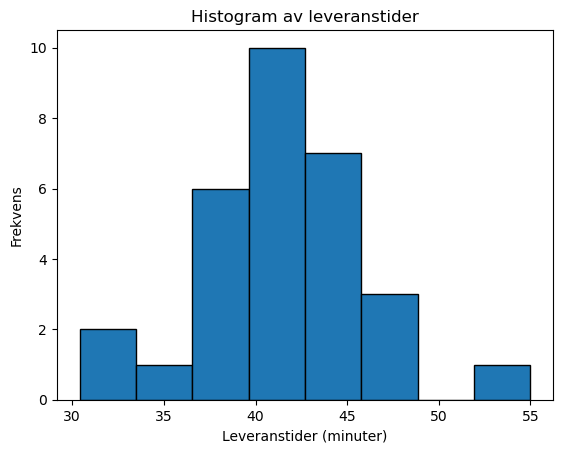

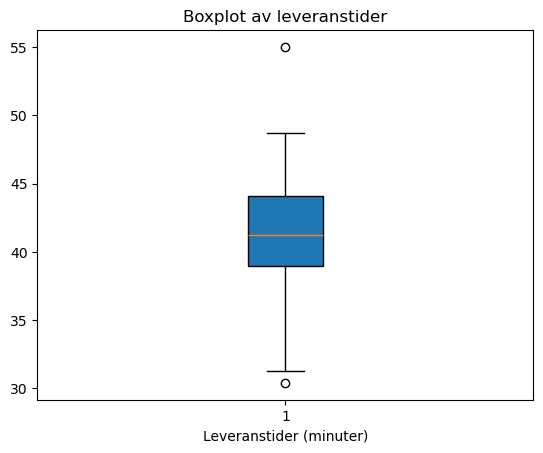

In [3]:
# Nu ska vi göra en diagram för att visa datan. Vi använder matplotlib för att skapa en histogram och en boxplot.


import matplotlib.pyplot as plt
# vi gör först histogram för att visa hur data fördelar sig.
def data_histogram(leveranstider):   
    plt.hist(leveranstider, bins=8, edgecolor='black')
    plt.xlabel("Leveranstider (minuter)")
    plt.ylabel("Frekvens")
    plt.title("Histogram av leveranstider")
    plt.show()


data_histogram(leveranstider)

# Nu gör vi en boxplot, boxplot är bra för att upptäcka median, spridning och eventuella outliers i datan.
def data_boxplot(leveranstider):
    plt.boxplot(leveranstider, patch_artist=True)
    plt.xlabel("Leveranstider (minuter)")
    plt.title("Boxplot av leveranstider")
    plt.show()

data_boxplot(leveranstider)

## vi ser i boxplot median är ca 41.25 och det finns några outliers som är över 50 minuter.


# H0 det finns ingen förändring i leveranstiderna
# HA det finns en förändring i leveranstiderna

In [4]:
from scipy import stats
from scipy.stats import ttest_1samp
import numpy as np

## funktionen ttest_1samp tar två argument: datan (leveranstider) 
# och det hypotetiska medelvärdet (popmean) som vi vill jämföra med.
#  I det här fallet är popmean=42, vilket är det hypotetiska medelvärdet/ kända populationenvärdet.

# H0​:μ=42 
result = ttest_1samp(leveranstider, popmean=42) 
## jag avrundade värderna till 3 decimaler för att göra det mer läsbart.
print("t-statistik: ", result.statistic.round(3))
print("p-värde: ", result.pvalue.round(3))

#p-värde(tvåsidigt):0,523 




medelvärde = np.mean(leveranstider)
median = np.median(leveranstider)
standardavvikelse = np.std(leveranstider, ddof=1)# ddof=1 för stickprovsstandardavvikelse
n = len(leveranstider)  

# beräkna 95% konfidensintervall för medelvärdet 
ci=stats.t.interval(0.95, df=n-1, loc=medelvärde, scale=standardavvikelse/np.sqrt(n))
print("95% konfidensintervall: ", np.round(ci, 3))

## tolkning
# vi jämförde p-värdet med signifikansnivån  α=0.05 
# eftersom 0.523 > 0.05 så kan vi inte förkasta nollhypotesen H0​.
#  Det betyder att det inte finns tillräckligt med bevis i datan för att säga att det genomsnittliga levernastiden har förändrats. 



# ----- ATT TÄNKA PÅ -----
# Skillnaden är ganska liten: 42 - 41.43 = 0.57 minuter./ ca 34 sekunder..
# En skillnad på 0.57 minuter kanske inte spelar så stor roll i logistisk verksamhet.
# Därför, även om skillnaden hade varit statistiskt signifikant,
# behöver den inte nödvändigtvis vara praktiskt betydelsefull.






    



t-statistik:  -0.646
p-värde:  0.523
95% konfidensintervall:  [39.611 43.242]


# 10

1. I denna undersökning vill vi se om de två programmen ger samma genomsnittliga testreultat.
Våra hypoteser är:

Ho: Det finns ingen skillnad i testresultat för program A och program B.

Ha: Det finns en skillnad i testresultat mellan program A och program B.

Testet är tvåsidigt och genomförs med signifikansnivå 5%.

In [5]:
import numpy as np
# Sätt ert gruppnummer här (t.ex. 1, 2, 3, ...).
gruppnummer = 23
# Skapa en RNG med ert gruppnummer som seed
rng = np.random.default_rng(gruppnummer)
# Basvärden för testpoäng
# Program A: något lägre medelvärde, Program B: något högre
loc_A_bas = 72.0
loc_B_bas = 76.0
# Låt medelvärdena variera svagt med gruppnumret
# Variation ungefär ±2 poäng runt basvärdena
delta_A = (gruppnummer % 5 - 2) * 0.6 # -1.2 .. +1.2
delta_B = (gruppnummer % 7 - 3) * 0.5 # -1.5 .. +1.5
loc_A = loc_A_bas + delta_A
loc_B = loc_B_bas + delta_B
# Basstandardavvikelse för båda programmen
scale_A_bas = 8.0
scale_B_bas = 8.5
# Låt spridningen variera svagt med gruppnumret
scale_A = scale_A_bas + (gruppnummer % 3 - 1) * 0.5 # ~ 7.0 .. 9.0
scale_B = scale_B_bas + (gruppnummer % 4 - 1.5) * 0.4 # ~ 7.9 .. 9.1
# Säkerställ att scale aldrig blir för liten
scale_A = max(scale_A, 1.0)
scale_B = max(scale_B, 1.0)
print(f"Grupp {gruppnummer}:")
print(f" Program A: loc = {loc_A:.2f}, scale = {scale_A:.2f}")
print(f" Program B: loc = {loc_B:.2f}, scale = {scale_B:.2f}")
# Generera 25 testpoäng per program
program_A = rng.normal(loc=loc_A, scale=scale_A, size=25)
program_B = rng.normal(loc=loc_B, scale=scale_B, size=25)
# Avrunda till en decimal
program_A = np.round(program_A, 1)
program_B = np.round(program_B, 1)
# Klipp poäng till intervallet [0, 100]
program_A = np.clip(program_A, a_min=0.0, a_max=100.0)
program_B = np.clip(program_B, a_min=0.0, a_max=100.0)
print("Program A (testpoäng):")
print(program_A)
print("Program B (testpoäng):")
print(program_B)

Grupp 23:
 Program A: loc = 72.60, scale = 8.50
 Program B: loc = 75.50, scale = 9.10
Program A (testpoäng):
[77.3 74.4 72.1 52.9 76.3 54.5 80.3 77.8 79.7 79.6 75.1 68.1 70.  85.4
 67.7 70.7 66.4 68.2 70.  74.8 70.1 69.6 67.4 73.4 61.2]
Program B (testpoäng):
[ 76.   87.4  68.5  75.1 100.   66.5  60.7  71.6  91.9  94.   64.4  80.7
  75.5  70.1  57.8  84.8  67.7  78.2  76.2  92.5  86.2  65.   73.1  84.9
  63.4]


2. Variablerna Program A och Program B innehåller testresultat 0-100 poäng från två oberoende grupper av nyanställda som medverkat i två olika introduktionsprogram. Varje variabel har 25st testresultat.
Program A är ett traditionellt föreläsnings program.
Program B är ett interaktivt program baserat på diskussioner och uppgifter.

In [6]:
print("Datatyp Program A:", type(program_A))
print("Datatyp Program B:", type(program_B))

Datatyp Program A: <class 'numpy.ndarray'>
Datatyp Program B: <class 'numpy.ndarray'>


3. Som vi ser från koden ovan är variablerna program_A och program_B av datatypen: numpy.ndarray.
Varje element i respektive vektor representerar testresultatet för en persons test efter genomförd introduktion.
Grupperna är oberoende eftersom olika personer deltagit i olika program.

In [7]:
import pandas as pd

pd.DataFrame({
    "Program A": program_A,
    "Program B": program_B
}).describe()

,Program A,Program B
count,25.000000,25.000000
mean,71.320000,76.488000
std,7.546412,11.356728
min,52.900000,57.800000
25%,68.100000,67.700000
50%,70.700000,75.500000
75%,76.300000,84.900000
max,85.400000,100.000000


Medianen motsvarar 50-percentilen i tabellen ovan.

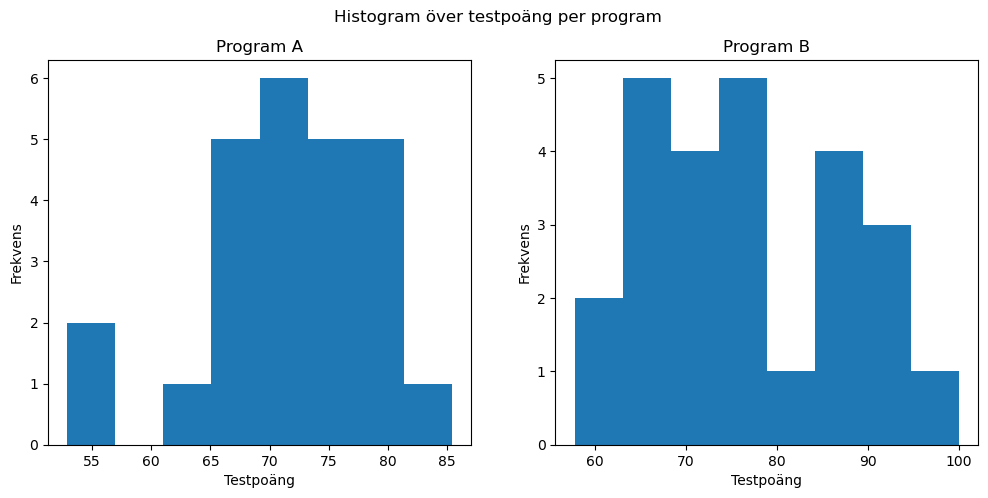

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(program_A, bins=8)
ax[0].set_title("Program A")
ax[0].set_xlabel("Testpoäng")
ax[0].set_ylabel("Frekvens")

ax[1].hist(program_B, bins=8)
ax[1].set_title("Program B")
ax[1].set_xlabel("Testpoäng")
ax[1].set_ylabel("Frekvens")

plt.suptitle("Histogram över testpoäng per program")

plt.show()

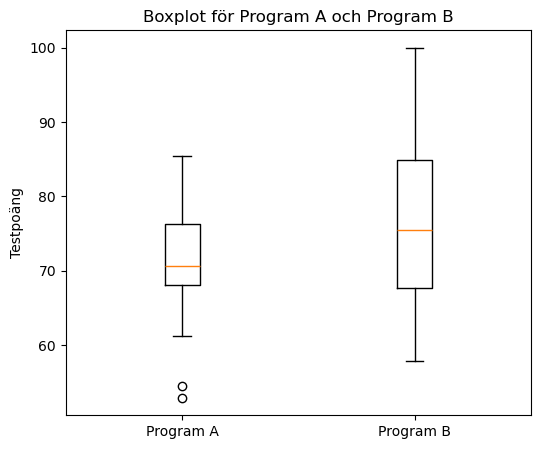

In [9]:
# Diagram 2: boxplot
plt.figure(figsize=(6,5))
plt.boxplot([program_A, program_B], labels=["Program A", "Program B"])
plt.ylabel("Testpoäng")
plt.title("Boxplot för Program A och Program B")
plt.show()

5.  Medelvärdet är ungefär 5 poäng högre för program B. Men program B har även en större spridning än program A. 
Vi kan därför inte avgöra en statistisk skillnad utifrån medelvärdena. 

In [10]:
from scipy.stats import ttest_ind
from scipy import stats

# Genomför t-testet. Vi använder Welch's t-test pga skilnnader i gruppernas varians.

t_stat, p_value = ttest_ind(program_A, program_B, equal_var=False)

# Skriver ut p och t-värdet.

print(f"t-värde = {t_stat:.3f}")
print(f"p-värde = {p_value:.5f}")

# Medelvärden
mean_A = np.mean(program_A)
mean_B = np.mean(program_B)

print(f"Medelvärde Program A = {mean_A:.2f}")
print(f"Medelvärde Program B = {mean_B:.2f}")

# Medelvärde A - medelvärde B.

diff = mean_A - mean_B

# Beräknar standardfelet

se = np.sqrt(
    np.var(program_A, ddof=1)/len(program_A)
    +
    np.var(program_B, ddof=1)/len(program_B)
)

# Beräknar frihetsgrader.

df = (
    (np.var(program_A, ddof=1)/len(program_A)
     +
     np.var(program_B, ddof=1)/len(program_B))**2
) / (
    ((np.var(program_A, ddof=1)/len(program_A))**2)/(len(program_A)-1)
    +
    ((np.var(program_B, ddof=1)/len(program_B))**2)/(len(program_B)-1)
)

# Hämta kritiskt t-värde.

t_crit = stats.t.ppf(0.975, df)

# Beräknar KI intervallet.

ci_low = diff - t_crit * se
ci_high = diff + t_crit * se

print(f"95% KI för skillnaden (A − B): [{ci_low:.3f}, {ci_high:.3f}]")

# Beslut
alpha = 0.05

if p_value < alpha:
    print("Vi förkastar H0")
else:
    print("Vi förkastar inte H0")

t-värde = -1.895
p-värde = 0.06502
Medelvärde Program A = 71.32
Medelvärde Program B = 76.49
95% KI för skillnaden (A − B): [-10.672, 0.336]
Vi förkastar inte H0


9. Eftersom p-värdet 0,064 är större än signifikansnivån 0,05 förkastar vi ej Ho. 
Det betyder att vi inte ser en tillräckligt stor statistisk skillnad mellan programmens olika resultat.

10. Program B hade ett något högre medelvärde, men eftersom skillnaden inte är statistiskt signifikant, kan inte HR-avdelningen med säkerhet säga att program B ger ett bättre genomsnittligt resultat än program A baserat på detta stickprov.

# 11

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Sätt ert gruppnummer här (t.ex. 1, 2, 3, ...). 
gruppnummer = 23 

# Skapa en RNG med ert gruppnummer som seed 
rng = np.random.default_rng(gruppnummer) 

# Antal spelare 
n = 20 

# Basnivå för resultat före träning 
loc_fore_bas = 58.0 
loc_fore = loc_fore_bas + (gruppnummer % 7 - 3) * 1.2 

# Spridning före träning 
scale_fore_bas = 6.5 
scale_fore = scale_fore_bas + (gruppnummer % 5 - 2) * 0.4 
scale_fore = max(scale_fore, 1.0) 

# Förväntad förbättring efter träning 
forbattring_bas = 4.0 
forbattring_loc = forbattring_bas + (gruppnummer % 6 - 2.5) * 0.5 

# Spridning i individuell förbättring 
forbattring_scale_bas = 2.4 
forbattring_scale = forbattring_scale_bas + (gruppnummer % 4 - 1.5) * 0.3 
forbattring_scale = max(forbattring_scale, 0.5) 

print(f"Grupp {gruppnummer}:") 
print(f"  före: loc = {loc_fore:.2f}, scale = {scale_fore:.2f}") 
print(f"  förbättring: loc = {forbattring_loc:.2f}, scale = {forbattring_scale:.2f}") 

# Generera resultat före träning 
fore = rng.normal(loc=loc_fore, scale=scale_fore, size=n) 
fore = np.round(fore, 1) 
fore = np.clip(fore, a_min=0.0, a_max=100.0) 

# Generera individuell förbättring 
forbattring = rng.normal(loc=forbattring_loc, scale=forbattring_scale, size=n) 
forbattring = np.round(forbattring, 1) 

# Beräkna resultat efter träning för samma spelare 
efter = fore + forbattring 
efter = np.round(efter, 1) 
efter = np.clip(efter, a_min=0.0, a_max=100.0) 

print("Före träning:") 
print(fore) 
print("Efter träning:") 
print(efter) 

Grupp 23:
  före: loc = 56.80, scale = 6.90
  förbättring: loc = 5.25, scale = 2.85
Före träning:
[60.6 58.3 56.4 40.8 59.8 42.1 63.1 61.  62.5 62.5 58.9 53.1 54.7 67.2
 52.8 55.2 51.8 53.2 54.7 58.6]
Efter träning:
[65.  62.5 59.9 46.3 61.2 47.5 72.1 64.1 67.6 75.8 61.3 53.7 58.7 77.6
 63.9 57.  58.7 58.5 58.3 58.3]


## Ha: Träningsinterventionen har ingen effekt på resultaten. Den genomsnittliga skillnaden i poäng är noll
## H0: Träningsinterventionen har en effekt på resultaten. Den genomsnittliga skillnaden i poäng är skild från noll

In [12]:
# fore: Spelarnas poäng på det standardiserade precisionstestet innan den mentala träningen.
# efter: Samma spelares poäng på precisionstestet efter att de har genomfört den mentala träningen.
#Både fore och efter är kvantitativa, kontinuerliga data

## Data

In [13]:
df = pd.DataFrame({'Före': fore, 'Efter': efter})
print("\n--- Sammanfattande statistik ---")
print(df.describe())


--- Sammanfattande statistik ---
            Före      Efter
count  20.000000  20.000000
mean   56.365000  61.400000
std     6.534546   7.930023
min    40.800000  46.300000
25%    53.175000  58.300000
50%    57.350000  60.550000
75%    60.700000  64.325000
max    67.200000  77.600000


### Visualisering

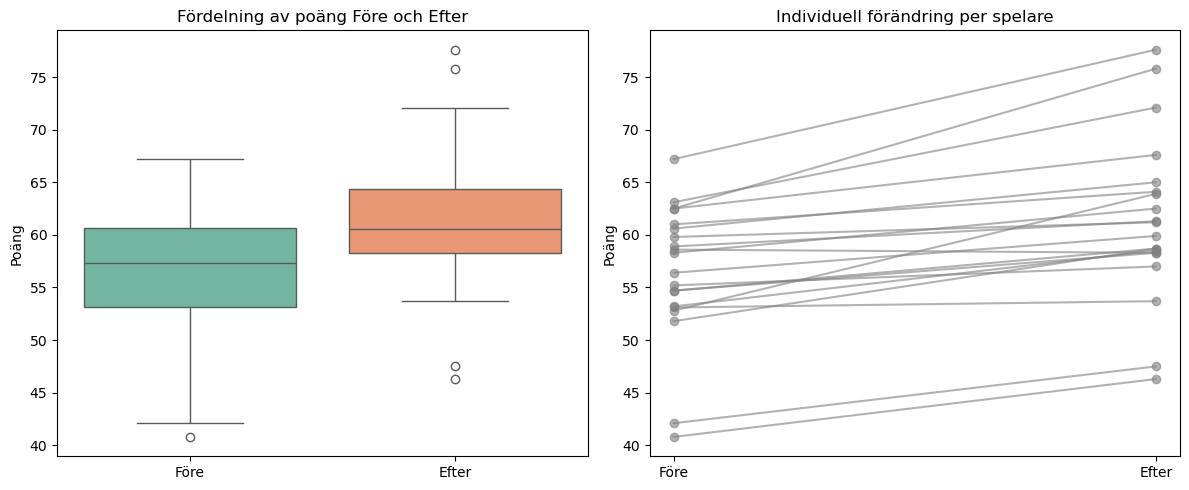

In [14]:
plt.figure(figsize=(12, 5))

# Diagram 1: Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=df, palette="Set2")
plt.title('Fördelning av poäng Före och Efter')
plt.ylabel('Poäng')

# Diagram 2: Slopegraph (linjediagram per individ)
plt.subplot(1, 2, 2)
for i in range(n):
    plt.plot([1, 2], [fore[i], efter[i]], marker='o', color='gray', alpha=0.6)
plt.xticks([1, 2], ['Före', 'Efter'])
plt.title('Individuell förändring per spelare')
plt.ylabel('Poäng')

plt.tight_layout()
plt.show()

### T-Test

In [15]:
# Scipy ttest_rel räknar ut t-värde och p-värde
t_stat, p_value = stats.ttest_rel(efter, fore)

mean_fore = np.mean(fore)
mean_efter = np.mean(efter)
diff = efter - fore
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)

# Beräkna 95% konfidensintervall för skillnaden
ci_diff = stats.t.interval(0.95, df=n-1, loc=mean_diff, scale=std_diff/np.sqrt(n))

print("\n--- Nyckelvärden ---")
print(f"t-värde: {t_stat:.3f}")
print(f"p-värde (tvåsidigt): {p_value:.5f}")
print(f"Medelvärde före: {mean_fore:.2f}")
print(f"Medelvärde efter: {mean_efter:.2f}")
print(f"95% CI för medelskillnaden: [{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]")



--- Nyckelvärden ---
t-värde: 6.302
p-värde (tvåsidigt): 0.00000
Medelvärde före: 56.36
Medelvärde efter: 61.40
95% CI för medelskillnaden: [3.363, 6.707]


## Beslut om H0

Vi förkastar H0 då pvärdet är mycket mindre än 0.05.

## Tolkning i kontext

Resultatet visar att den mentala träningen hadde enpositiv effekt på lagets precision. Om en ökad träffsäkerhet med 3 till 6 poäng på detta test är avgörande för vem som vinner en riktig bågskyttetävling, så har denna mentala träning inte bara statistisk signifikans utan är även av högsta praktiska relevans för lagets framgång